In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv('C:\\Users\\mohit\\Downloads\\services-2025-10.csv\\services-2025-10.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1952924 entries, 0 to 1952923
Data columns (total 20 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   Service:RDT-ID                int64  
 1   Service:Date                  object 
 2   Service:Type                  object 
 3   Service:Company               object 
 4   Service:Train number          int64  
 5   Service:Completely cancelled  bool   
 6   Service:Partly cancelled      bool   
 7   Service:Maximum delay         int64  
 8   Stop:RDT-ID                   int64  
 9   Stop:Station code             object 
 10  Stop:Station name             object 
 11  Stop:Arrival time             object 
 12  Stop:Arrival delay            float64
 13  Stop:Arrival cancelled        object 
 14  Stop:Departure time           object 
 15  Stop:Departure delay          float64
 16  Stop:Departure cancelled      object 
 17  Stop:Platform change          bool   
 18  Stop:Planned platform 

In [6]:
df.describe()

,Service:RDT-ID,Service:Train number,Service:Maximum delay,Stop:RDT-ID,Stop:Arrival delay,Stop:Departure delay
count,1.952924e+06,1.952924e+06,1.952924e+06,1.952924e+06,1.732941e+06,1.732868e+06
mean,1.699941e+07,7.621400e+04,2.461606e-01,1.537535e+08,1.079504e+00,9.901943e-01
std,6.496264e+04,2.160388e+05,1.743848e+00,5.648048e+05,3.503835e+00,3.236411e+00
min,1.688863e+07,1.200000e+02,0.000000e+00,1.527706e+08,0.000000e+00,0.000000e+00
25%,1.694232e+07,4.338000e+03,0.000000e+00,1.532653e+08,0.000000e+00,0.000000e+00
50%,1.699919e+07,6.780000e+03,0.000000e+00,1.537535e+08,0.000000e+00,0.000000e+00
75%,1.705649e+07,3.096800e+04,0.000000e+00,1.542417e+08,1.000000e+00,1.000000e+00
max,1.712736e+07,9.720940e+05,2.860000e+02,1.548999e+08,2.860000e+02,2.860000e+02


In [4]:
df.isnull().sum()

Service:RDT-ID                       0
Service:Date                         0
Service:Type                         0
Service:Company                      0
Service:Train number                 0
Service:Completely cancelled         0
Service:Partly cancelled             0
Service:Maximum delay                0
Stop:RDT-ID                          0
Stop:Station code                 2295
Stop:Station name                    0
Stop:Arrival time               219983
Stop:Arrival delay              219983
Stop:Arrival cancelled          219983
Stop:Departure time             220056
Stop:Departure delay            220056
Stop:Departure cancelled        220056
Stop:Platform change                 0
Stop:Planned platform           285531
Stop:Actual platform            285531
dtype: int64

In [7]:
(df.isnull().sum() / len(df)) * 100

Service:RDT-ID                   0.000000
Service:Date                     0.000000
Service:Type                     0.000000
Service:Company                  0.000000
Service:Train number             0.000000
Service:Completely cancelled     0.000000
Service:Partly cancelled         0.000000
Service:Maximum delay            0.000000
Stop:RDT-ID                      0.000000
Stop:Station code                0.117516
Stop:Station name                0.000000
Stop:Arrival time               11.264289
Stop:Arrival delay              11.264289
Stop:Arrival cancelled          11.264289
Stop:Departure time             11.268027
Stop:Departure delay            11.268027
Stop:Departure cancelled        11.268027
Stop:Platform change             0.000000
Stop:Planned platform           14.620692
Stop:Actual platform            14.620692
dtype: float64

In [17]:
#how many minutes delayed:
target = 'Service:Maximum delay'
df[target].describe()



count    1.952924e+06
mean     2.461606e-01
std      1.743848e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.860000e+02
Name: Service:Maximum delay, dtype: float64

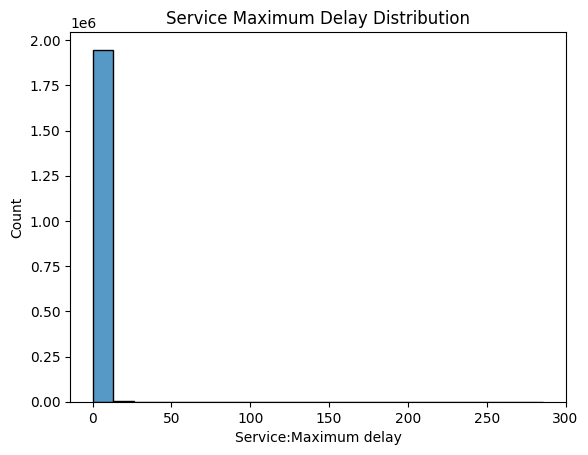

In [19]:
sns.histplot(df[target])
plt.title('Service Maximum Delay Distribution')
plt.show()



In [21]:
df['delay'] = df['Service:Maximum delay'].apply(lambda x: 1 if x > 0 else 0)
df['delay'].value_counts()


delay
0    1811883
1     141041
Name: count, dtype: int64

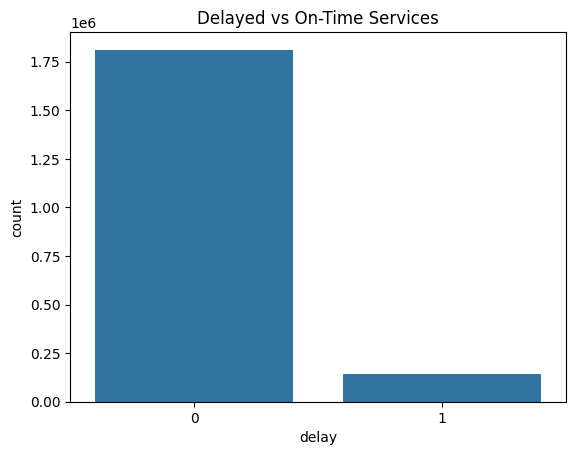

In [22]:
sns.countplot(x='delay', data=df)
plt.title('Delayed vs On-Time Services')
plt.show()

In [26]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

num_cols, cat_cols


(Index(['Service:RDT-ID', 'Service:Train number', 'Service:Maximum delay',
        'Stop:RDT-ID', 'Stop:Arrival delay', 'Stop:Departure delay', 'delay'],
       dtype='object'),
 Index(['Service:Date', 'Service:Type', 'Service:Company', 'Stop:Station code',
        'Stop:Station name', 'Stop:Arrival time', 'Stop:Arrival cancelled',
        'Stop:Departure time', 'Stop:Departure cancelled',
        'Stop:Planned platform', 'Stop:Actual platform'],
       dtype='object'))

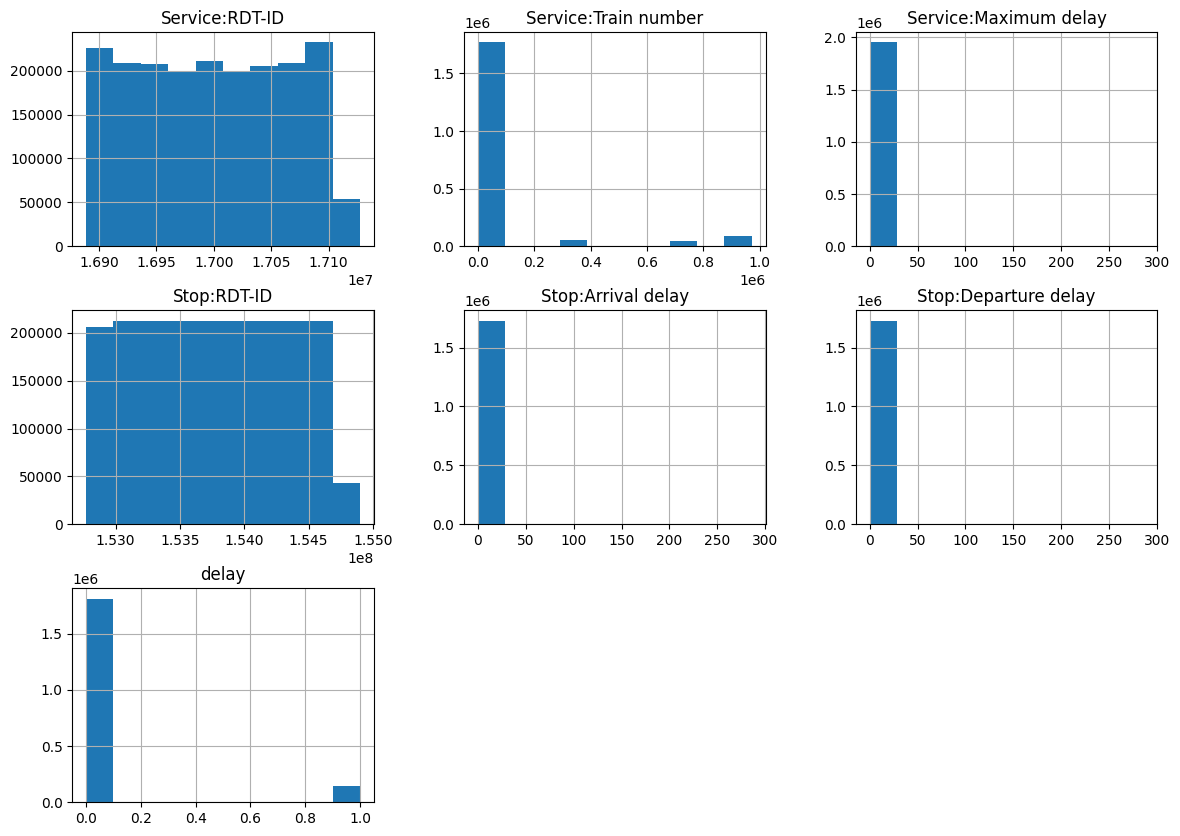

In [27]:
df[num_cols].hist(figsize=(14,10))
plt.show()


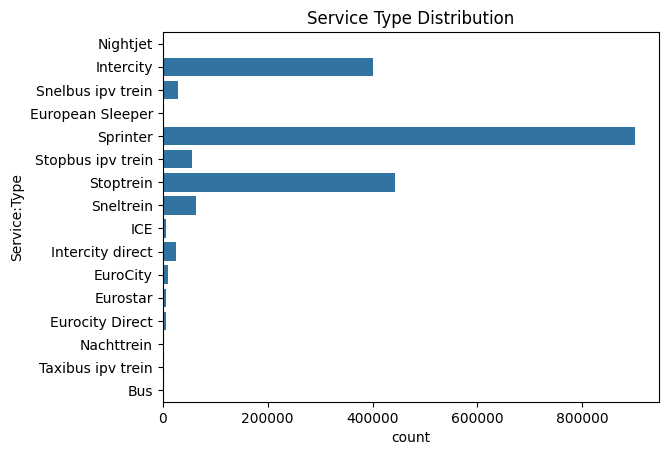

In [28]:
sns.countplot(y='Service:Type', data=df)
plt.title('Service Type Distribution')
plt.show()


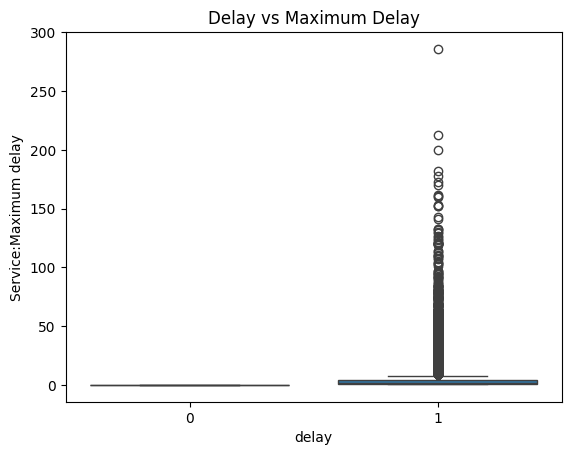

In [30]:
#delay vs Numeric Features
sns.boxplot(x='delay', y='Service:Maximum delay', data=df)
plt.title('Delay vs Maximum Delay')
plt.show()


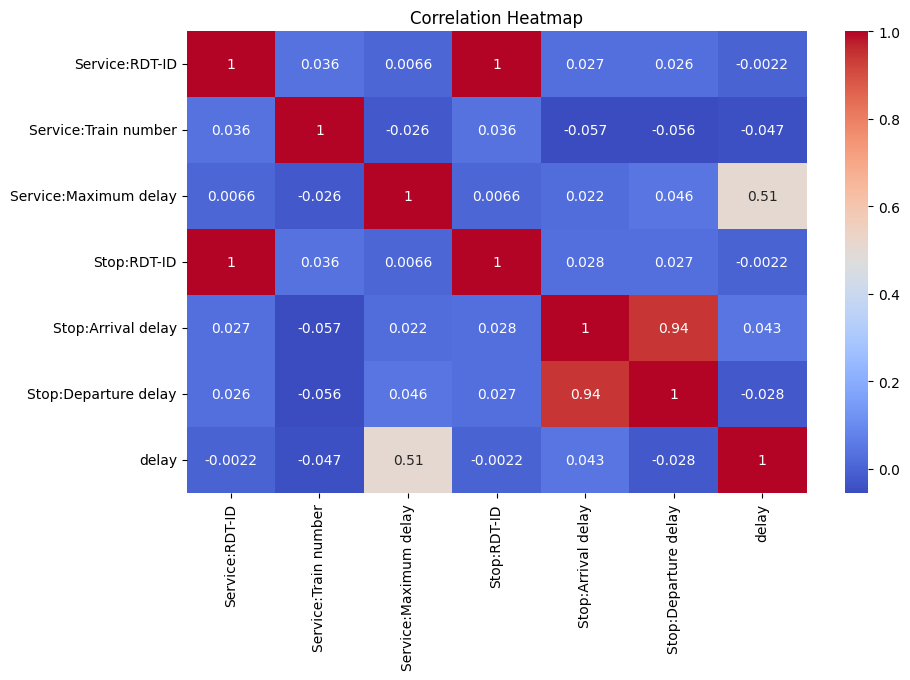

In [31]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [33]:
#drop leakage columns
leakage_cols = [
    'Service:Maximum delay',
    'Stop:Arrival delay',
    'Stop:Departure delay'
]

df_model = df.drop(columns=leakage_cols)


In [34]:
#Seperating features and target
X = df_model.drop('delay', axis=1)
y = df_model['delay']